# Modelo BaseLine

**Autora:** Leydy Osorio Vargas  
**Fecha:** 2026-09-08

## Descripción

Este notebook construye una referencia mínima y reproducible para el problema de clasificación de enfermedad cardiaca. Se comparan dos modelos `DummyClassifier` con una heurística de una sola regla aprendida mediante un árbol de profundidad uno.

El pipeline completo de Feature Engineering de la Tarea 4 se ajusta dentro de cada partición de entrenamiento para evitar fuga de información. El objetivo no es obtener el mejor modelo posible, sino establecer un punto de comparación transparente para la selección de modelos de la siguiente tarea.


## Alcance y criterio de evaluación

- La fuente es `data/02_intermediate/corazon_type_fixed.parquet`.
- Se eliminan duplicados exactos antes de separar train y test.
- Las observaciones sin `disease` no participan en entrenamiento supervisado y el target no se imputa.
- Se conserva un 20 % como test final estratificado y no se utiliza para seleccionar el baseline.
- La comparación de candidatos se realiza mediante validación cruzada estratificada de cinco folds sobre train.
- La métrica principal es **recall/sensibilidad** de la clase positiva, porque un falso negativo dejaría sin priorización a una persona que sí presenta la condición.
- Se reportan además especificidad, precisión, F1, balanced accuracy y ROC AUC.
- La heurística de una regla se usa para obtener una variable interpretable; no constituye una regla clínica.
- Solo se muestran resultados agregados, nunca registros individuales.


## 📚 Importar librerías y configurar reproducibilidad


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    balanced_accuracy_score,
    confusion_matrix,
    f1_score,
    make_scorer,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import (
    StratifiedKFold,
    cross_validate,
    learning_curve,
    train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, RobustScaler
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.utils.validation import check_is_fitted

RANDOM_STATE = 42
TEST_SIZE = 0.20
CV_FOLDS = 5
PARALLEL_JOBS = 1
MIN_SAMPLES_PER_LEAF = 20
MAX_TARGET_RATE_DIFFERENCE = 0.02
TARGET = "disease"
POSITIVE_CLASS = 1
NEGATIVE_CLASS = 0

print(f"Pandas: {pd.__version__}")
print(f"Scikit-learn: {sklearn.__version__}")

Pandas: 3.0.5
Scikit-learn: 1.9.0


## 💾 Cargar y preparar los datos


In [2]:
PROJECT_DIR = Path.cwd().resolve()

if not (PROJECT_DIR / "data").is_dir():
    PROJECT_DIR = next(
        parent
        for parent in PROJECT_DIR.parents
        if (parent / "data").is_dir() and (parent / "pyproject.toml").exists()
    )

INTERMEDIATE_FILE = PROJECT_DIR / "data" / "02_intermediate" / "corazon_type_fixed.parquet"

if not INTERMEDIATE_FILE.exists():
    raise FileNotFoundError(
        "No se encontró el Parquet intermedio. Ejecute primero el notebook de la "
        "Tarea 2: notebooks/2-exploration/02.Exploracion-ljov-2026-09-06.ipynb"
    )

heart_df = pd.read_parquet(INTERMEDIATE_FILE)
unique_df = heart_df.drop_duplicates().copy()
unlabeled_df = unique_df.loc[unique_df[TARGET].isna()].copy()
modeling_df = unique_df.loc[unique_df[TARGET].notna()].copy()

preparation_summary = pd.DataFrame(
    {
        "rows": [
            len(heart_df),
            int(heart_df.duplicated().sum()),
            len(unique_df),
            len(unlabeled_df),
            len(modeling_df),
        ]
    },
    index=[
        "original_rows",
        "exact_duplicates_removed",
        "unique_rows",
        "unique_rows_without_target",
        "rows_available_for_modeling",
    ],
)

preparation_summary

,rows
original_rows,3030
exact_duplicates_removed,2462
unique_rows,568
unique_rows_without_target,88
rows_available_for_modeling,480


## ✂️ Crear un test final independiente


In [3]:
X = modeling_df.drop(columns=TARGET)
y = modeling_df[TARGET].astype("int8")

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
)

split_summary = pd.DataFrame(
    {
        "rows": [len(X_train), len(X_test)],
        "positive_rate_pct": [y_train.mean() * 100, y_test.mean() * 100],
    },
    index=["train", "test"],
)

split_summary.round(2)

,rows,positive_rate_pct
train,384,47.92
test,96,47.92


In [4]:
train_hashes = set(pd.util.hash_pandas_object(X_train.astype("string"), index=False))
test_hashes = set(pd.util.hash_pandas_object(X_test.astype("string"), index=False))

split_validations = {
    "no_shared_indices": X_train.index.intersection(X_test.index).empty,
    "no_identical_predictor_rows": not train_hashes.intersection(test_hashes),
    "target_rate_difference_below_limit": (
        abs(y_train.mean() - y_test.mean()) < MAX_TARGET_RATE_DIFFERENCE
    ),
    "binary_target": set(y_train.unique()).union(y_test.unique())
    == {NEGATIVE_CLASS, POSITIVE_CLASS},
}

split_validation_summary = pd.Series(split_validations, name="passed").to_frame()
assert split_validation_summary["passed"].all(), split_validation_summary

split_validation_summary

,passed
no_shared_indices,True
no_identical_predictor_rows,True
target_rate_difference_below_limit,True
binary_target,True


## 🧱 Reutilizar el pipeline de Feature Engineering

La definición siguiente reproduce el pipeline desarrollado y validado en la Tarea 4. En esta tarea no se transforma todo el dataset de antemano: el objeto completo se incorpora dentro de cada candidato, de manera que imputadores, encoders, escaladores y atributos derivados se ajusten nuevamente en cada fold de entrenamiento.


In [5]:
class HeartFeatureEngineer(BaseEstimator, TransformerMixin):
    """Normaliza tipos y agrega hipótesis de atributos sin ajustar estadísticas."""

    derived_features = (
        "age_squared",
        "old_peak_slope_interaction",
        "max_hr_old_peak_interaction",
        "chest_pain_exang",
    )
    numeric_input = (
        "age",
        "rest_bp",
        "chol",
        "max_hr",
        "old_peak",
        "slope",
        "ca",
    )
    binary_input = ("fbs", "exang")
    nominal_input = ("sex", "chest_pain", "rest_ecg", "thal")

    def fit(self, X, y=None):
        if not isinstance(X, pd.DataFrame):
            raise TypeError("HeartFeatureEngineer requiere un pandas DataFrame.")
        self.feature_names_in_ = np.asarray(X.columns, dtype=object)
        return self

    def transform(self, X):
        check_is_fitted(self, "feature_names_in_")
        transformed = X.copy()

        for column in self.numeric_input:
            transformed[column] = pd.to_numeric(transformed[column], errors="coerce").astype(float)

        for column in self.binary_input:
            mapped = transformed[column].map({False: 0.0, True: 1.0})
            transformed[column] = mapped.to_numpy(dtype=float, na_value=np.nan)

        for column in self.nominal_input:
            values = transformed[column].astype("string")
            transformed[column] = values.astype(object).where(values.notna(), np.nan)

        transformed["age_squared"] = transformed["age"] ** 2
        transformed["old_peak_slope_interaction"] = transformed["old_peak"] * transformed["slope"]
        transformed["max_hr_old_peak_interaction"] = transformed["max_hr"] * transformed["old_peak"]

        exang_label = transformed["exang"].map({0.0: "no", 1.0: "yes"})
        valid_interaction = transformed["chest_pain"].notna() & exang_label.notna()
        chest_pain_exang = pd.Series(
            np.nan,
            index=transformed.index,
            dtype=object,
        )
        chest_pain_exang.loc[valid_interaction] = (
            transformed.loc[valid_interaction, "chest_pain"].astype(str)
            + "__"
            + exang_label.loc[valid_interaction]
        )
        transformed["chest_pain_exang"] = chest_pain_exang
        return transformed

    def get_feature_names_out(self, input_features=None):
        check_is_fitted(self, "feature_names_in_")
        base_features = (
            self.feature_names_in_
            if input_features is None
            else np.asarray(input_features, dtype=object)
        )
        return np.asarray(
            [*base_features, *self.derived_features],
            dtype=object,
        )

In [6]:
numeric_features = [
    "age",
    "rest_bp",
    "chol",
    "max_hr",
    "old_peak",
    "ca",
    "age_squared",
    "old_peak_slope_interaction",
    "max_hr_old_peak_interaction",
]
binary_features = ["fbs", "exang"]
ordinal_features = ["slope"]
nominal_features = [
    "sex",
    "chest_pain",
    "rest_ecg",
    "thal",
    "chest_pain_exang",
]

numeric_pipeline = Pipeline(
    [
        (
            "imputer",
            SimpleImputer(
                strategy="median",
                add_indicator=True,
                keep_empty_features=True,
            ),
        ),
        ("scaler", RobustScaler()),
    ]
)
binary_pipeline = Pipeline(
    [
        (
            "imputer",
            SimpleImputer(strategy="most_frequent", keep_empty_features=True),
        )
    ]
)
ordinal_pipeline = Pipeline(
    [
        (
            "imputer",
            SimpleImputer(strategy="most_frequent", keep_empty_features=True),
        )
    ]
)
nominal_pipeline = Pipeline(
    [
        (
            "imputer",
            SimpleImputer(
                strategy="constant",
                fill_value="missing",
                keep_empty_features=True,
            ),
        ),
        (
            "onehot",
            OneHotEncoder(handle_unknown="ignore", sparse_output=False),
        ),
    ]
)

preprocessor = ColumnTransformer(
    [
        ("numeric", numeric_pipeline, numeric_features),
        ("binary", binary_pipeline, binary_features),
        ("ordinal", ordinal_pipeline, ordinal_features),
        ("nominal", nominal_pipeline, nominal_features),
    ],
    remainder="drop",
    verbose_feature_names_out=True,
)

feature_pipeline = Pipeline(
    [
        ("feature_engineering", HeartFeatureEngineer()),
        ("preprocessor", preprocessor),
    ]
)

print("Pipeline de Feature Engineering reconstruido correctamente.")

Pipeline de Feature Engineering reconstruido correctamente.


## 🧪 Definir modelos y métricas baseline


In [7]:
recall_scorer = make_scorer(recall_score, zero_division=0)
scoring = {
    "recall": recall_scorer,
    "specificity": make_scorer(
        recall_score,
        pos_label=NEGATIVE_CLASS,
        zero_division=0,
    ),
    "precision": make_scorer(precision_score, zero_division=0),
    "f1": make_scorer(f1_score, zero_division=0),
    "balanced_accuracy": make_scorer(balanced_accuracy_score),
    "roc_auc": "roc_auc",
}

candidate_estimators = {
    "Dummy: clase mayoritaria": DummyClassifier(strategy="most_frequent"),
    "Dummy: estratificado": DummyClassifier(
        strategy="stratified",
        random_state=RANDOM_STATE,
    ),
    "Heurística: una regla": DecisionTreeClassifier(
        max_depth=1,
        min_samples_leaf=MIN_SAMPLES_PER_LEAF,
        class_weight="balanced",
        random_state=RANDOM_STATE,
    ),
}

candidate_pipelines = {
    name: Pipeline(
        [
            ("features", clone(feature_pipeline)),
            ("model", clone(estimator)),
        ]
    )
    for name, estimator in candidate_estimators.items()
}

cross_validation = StratifiedKFold(
    n_splits=CV_FOLDS,
    shuffle=True,
    random_state=RANDOM_STATE,
)

pd.DataFrame(
    {
        "candidate": list(candidate_pipelines),
        "purpose": [
            "Predecir siempre la clase más frecuente",
            "Predecir según la proporción observada del target",
            "Aprender una única regla interpretable",
        ],
    }
).set_index("candidate")

,purpose
candidate,
Dummy: clase mayoritaria,Predecir siempre la clase más frecuente
Dummy: estratificado,Predecir según la proporción observada del target
Heurística: una regla,Aprender una única regla interpretable


## 🔁 Comparar candidatos mediante validación cruzada


In [8]:
validation_results = {}

for candidate_name, candidate_pipeline in candidate_pipelines.items():
    validation_results[candidate_name] = cross_validate(
        candidate_pipeline,
        X_train,
        y_train,
        cv=cross_validation,
        scoring=scoring,
        return_train_score=True,
        n_jobs=PARALLEL_JOBS,
    )

comparison_rows = []
for candidate_name, result in validation_results.items():
    row = {"candidate": candidate_name}
    for metric_name in scoring:
        scores = result[f"test_{metric_name}"]
        row[f"{metric_name}_mean"] = scores.mean()
        row[f"{metric_name}_std"] = scores.std()
    row["fit_time_mean_seconds"] = result["fit_time"].mean()
    comparison_rows.append(row)

cv_comparison = (
    pd.DataFrame(comparison_rows).set_index("candidate").sort_values("recall_mean", ascending=False)
)

cv_comparison.round(3)

,recall_mean,recall_std,specificity_mean,specificity_std,precision_mean,precision_std,f1_mean,f1_std,balanced_accuracy_mean,balanced_accuracy_std,roc_auc_mean,roc_auc_std,fit_time_mean_seconds
candidate,,,,,,,,,,,,,
Heurística: una regla,0.745,0.062,0.74,0.044,0.726,0.029,0.734,0.035,0.742,0.027,0.742,0.027,0.049
Dummy: estratificado,0.462,0.052,0.55,0.045,0.486,0.051,0.474,0.051,0.506,0.048,0.506,0.048,0.039
Dummy: clase mayoritaria,0.000,0.000,1.00,0.000,0.000,0.000,0.000,0.000,0.500,0.000,0.500,0.000,0.039


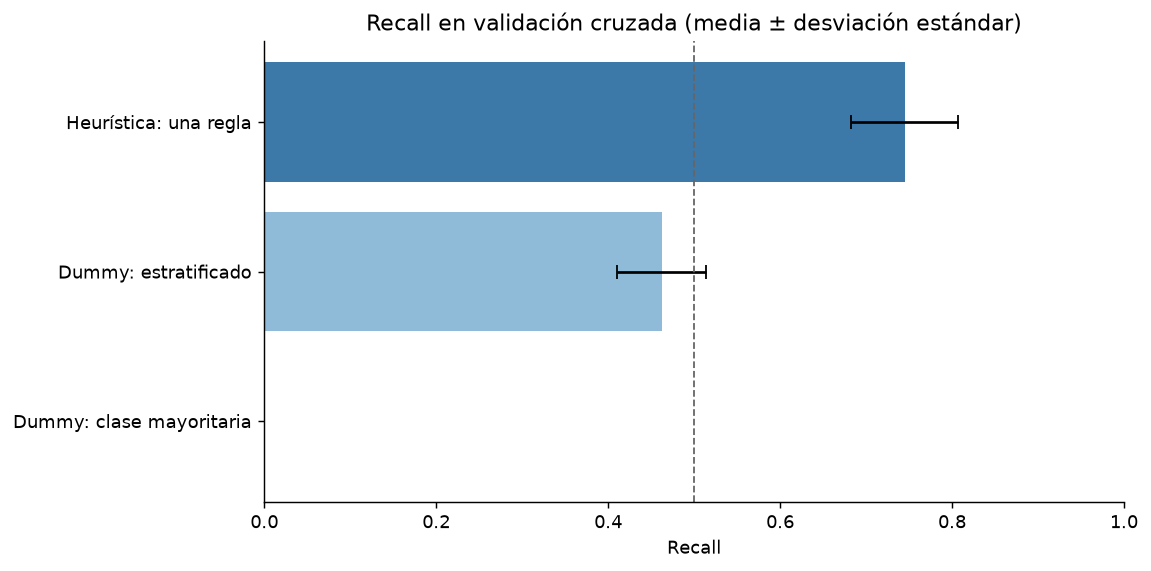

In [9]:
fig, ax = plt.subplots(figsize=(9, 4.5))
ordered = cv_comparison.sort_values("recall_mean")
ax.barh(
    ordered.index,
    ordered["recall_mean"],
    xerr=ordered["recall_std"],
    color=["#B7C9E2", "#8FBBD9", "#3C78A8"],
    capsize=4,
)
ax.axvline(0.5, color="#666666", linestyle="--", linewidth=1)
ax.set(
    title="Recall en validación cruzada (media ± desviación estándar)",
    xlabel="Recall",
    xlim=(0, 1),
)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

### Interpretación de la comparación

- El dummy de clase mayoritaria obtiene recall igual a cero: nunca identifica la clase positiva y, por tanto, no es una referencia aceptable para el objetivo de priorización.
- El dummy estratificado se aproxima al azar y obtiene un recall medio cercano a 0,46.
- La heurística de una regla obtiene un recall medio cercano a **0,745**, con una desviación estándar aproximada de **0,062**. También mantiene un mejor equilibrio entre sensibilidad y especificidad.
- La heurística se selecciona como baseline funcional. Su ventaja sobre los dummies establece una referencia mínima que los modelos posteriores deberán superar con validación rigurosa.


## 🏁 Ajustar el baseline seleccionado y evaluar el test


In [10]:
selected_name = cv_comparison.index[0]
selected_pipeline = clone(candidate_pipelines[selected_name])
selected_pipeline.fit(X_train, y_train)

test_prediction = selected_pipeline.predict(X_test)
test_probability = selected_pipeline.predict_proba(X_test)[:, POSITIVE_CLASS]
tn, fp, fn, tp = confusion_matrix(y_test, test_prediction).ravel()

test_metrics = pd.Series(
    {
        "recall_sensitivity": recall_score(y_test, test_prediction),
        "specificity": recall_score(
            y_test,
            test_prediction,
            pos_label=NEGATIVE_CLASS,
        ),
        "precision": precision_score(y_test, test_prediction),
        "f1": f1_score(y_test, test_prediction),
        "balanced_accuracy": balanced_accuracy_score(y_test, test_prediction),
        "roc_auc": roc_auc_score(y_test, test_probability),
    },
    name="test_score",
).to_frame()

print(f"Baseline seleccionado: {selected_name}")
test_metrics.round(3)

Baseline seleccionado: Heurística: una regla


,test_score
recall_sensitivity,0.848
specificity,0.680
precision,0.709
f1,0.772
balanced_accuracy,0.764
roc_auc,0.764


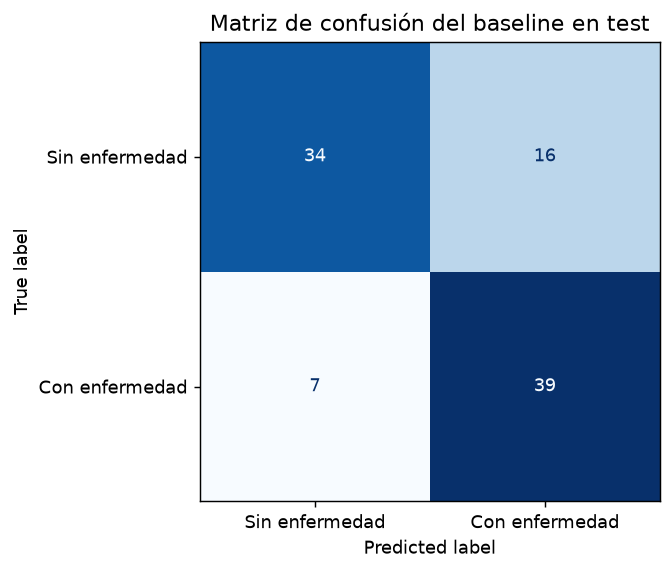

In [11]:
fig, ax = plt.subplots(figsize=(5.5, 4.5))
ConfusionMatrixDisplay(
    confusion_matrix=np.array([[tn, fp], [fn, tp]]),
    display_labels=["Sin enfermedad", "Con enfermedad"],
).plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title("Matriz de confusión del baseline en test")
plt.tight_layout()
plt.show()

In [12]:
error_summary = pd.Series(
    {
        "true_negatives": tn,
        "false_positives": fp,
        "false_negatives": fn,
        "true_positives": tp,
    },
    name="test_cases",
).to_frame()

error_summary

,test_cases
true_negatives,34
false_positives,16
false_negatives,7
true_positives,39


En las 96 observaciones reservadas para test, el baseline identifica 39 de los 46 casos positivos y deja 7 falsos negativos. El recall es aproximadamente **84,8 %**, mientras la especificidad es **68,0 %**. La diferencia frente al promedio de validación cruzada debe interpretarse como variabilidad muestral y no como evidencia de un rendimiento clínico garantizado.

Los 16 falsos positivos representan personas que serían priorizadas innecesariamente por la regla. En un sistema de apoyo a priorización este error puede ser menos grave que omitir un caso positivo, pero genera carga de seguimiento y debe controlarse.


## 🔎 Seleccionar e interpretar la variable más importante


In [13]:
transformed_feature_names = selected_pipeline.named_steps["features"].get_feature_names_out()
baseline_model = selected_pipeline.named_steps["model"]
feature_importance = pd.Series(
    baseline_model.feature_importances_,
    index=transformed_feature_names,
    name="importance",
).sort_values(ascending=False)

most_important_feature = feature_importance.index[0]
split_threshold = baseline_model.tree_.threshold[0]

importance_summary = pd.DataFrame(
    {
        "value": [
            most_important_feature,
            split_threshold,
            feature_importance.iloc[0],
        ]
    },
    index=["transformed_feature", "split_threshold", "importance"],
)

importance_summary

,value
transformed_feature,nominal__thal_normal
split_threshold,0.5
importance,1.0


In [14]:
baseline_rule = export_text(
    baseline_model,
    feature_names=list(transformed_feature_names),
)
print(baseline_rule)

|--- nominal__thal_normal <= 0.50
|   |--- class: 1
|--- nominal__thal_normal >  0.50
|   |--- class: 0



La variable seleccionada es `thal`, específicamente el indicador One-Hot `thal_normal`. La regla aprendida exclusivamente con train clasifica como positiva una observación cuando `thal` no está registrado como `normal`, y como negativa cuando sí lo está.

Se justifica su selección porque es el único atributo utilizado por el árbol de profundidad uno para reducir la impureza. Es una asociación predictiva simple, no una relación causal ni una regla médica. Además, el indicador reúne otras categorías y valores faltantes en la rama positiva, por lo que modelos posteriores deberán aprender relaciones más matizadas.


## 📈 Curva de aprendizaje


In [15]:
learning_sizes, learning_train_scores, learning_validation_scores, fit_times, _ = learning_curve(
    clone(selected_pipeline),
    X_train,
    y_train,
    train_sizes=np.linspace(0.25, 1.0, 6),
    cv=cross_validation,
    scoring=recall_scorer,
    n_jobs=PARALLEL_JOBS,
    shuffle=True,
    random_state=RANDOM_STATE,
    return_times=True,
)

learning_summary = pd.DataFrame(
    {
        "training_rows": learning_sizes,
        "train_recall_mean": learning_train_scores.mean(axis=1),
        "train_recall_std": learning_train_scores.std(axis=1),
        "validation_recall_mean": learning_validation_scores.mean(axis=1),
        "validation_recall_std": learning_validation_scores.std(axis=1),
        "fit_time_mean_seconds": fit_times.mean(axis=1),
        "fit_time_std_seconds": fit_times.std(axis=1),
    }
)

learning_summary.round(3)

,training_rows,train_recall_mean,train_recall_std,validation_recall_mean,validation_recall_std,fit_time_mean_seconds,fit_time_std_seconds
0,76,0.664,0.100,0.631,0.144,0.036,0.005
1,122,0.710,0.066,0.669,0.088,0.031,0.000
2,168,0.683,0.104,0.680,0.133,0.035,0.002
3,214,0.729,0.070,0.718,0.069,0.042,0.006
4,260,0.723,0.064,0.718,0.069,0.035,0.003
5,307,0.746,0.015,0.745,0.062,0.038,0.004


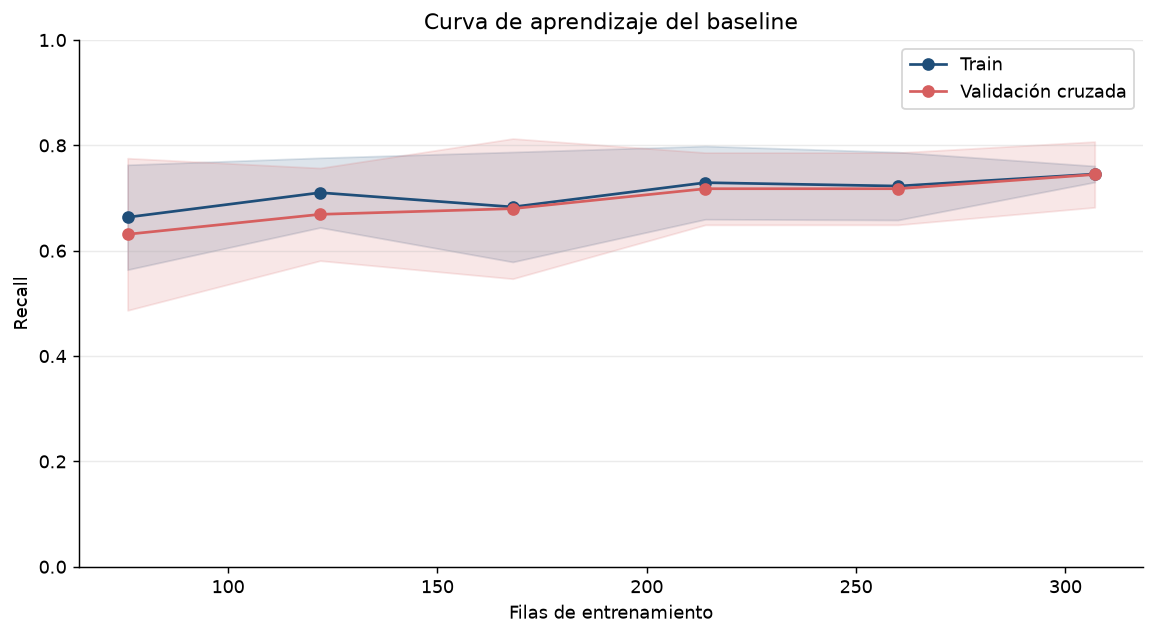

In [16]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(
    learning_summary["training_rows"],
    learning_summary["train_recall_mean"],
    marker="o",
    label="Train",
    color="#1F4E79",
)
ax.fill_between(
    learning_summary["training_rows"],
    learning_summary["train_recall_mean"] - learning_summary["train_recall_std"],
    learning_summary["train_recall_mean"] + learning_summary["train_recall_std"],
    alpha=0.15,
    color="#1F4E79",
)
ax.plot(
    learning_summary["training_rows"],
    learning_summary["validation_recall_mean"],
    marker="o",
    label="Validación cruzada",
    color="#D65F5F",
)
ax.fill_between(
    learning_summary["training_rows"],
    learning_summary["validation_recall_mean"] - learning_summary["validation_recall_std"],
    learning_summary["validation_recall_mean"] + learning_summary["validation_recall_std"],
    alpha=0.15,
    color="#D65F5F",
)
ax.set(
    title="Curva de aprendizaje del baseline",
    xlabel="Filas de entrenamiento",
    ylabel="Recall",
    ylim=(0, 1),
)
ax.legend()
ax.grid(axis="y", alpha=0.25)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

## ⏱️ Escalabilidad: tiempo de entrenamiento y score


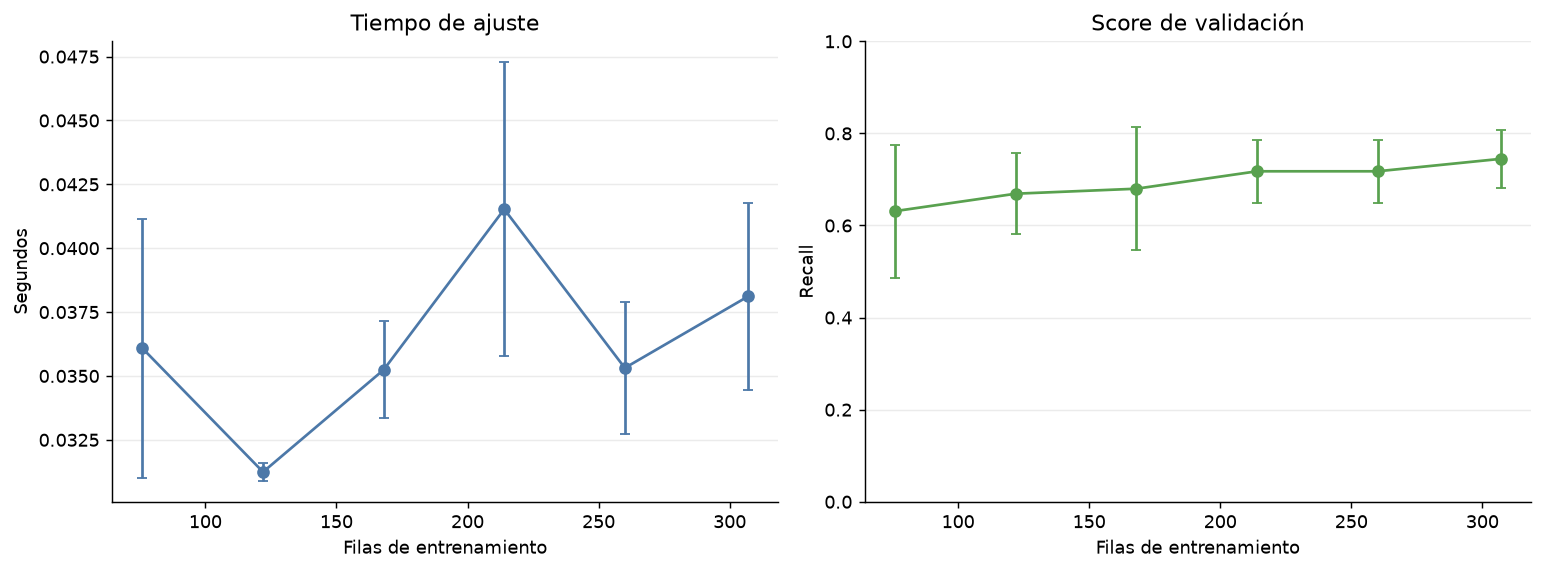

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].errorbar(
    learning_summary["training_rows"],
    learning_summary["fit_time_mean_seconds"],
    yerr=learning_summary["fit_time_std_seconds"],
    marker="o",
    capsize=3,
    color="#4C78A8",
)
axes[0].set(
    title="Tiempo de ajuste",
    xlabel="Filas de entrenamiento",
    ylabel="Segundos",
)

axes[1].errorbar(
    learning_summary["training_rows"],
    learning_summary["validation_recall_mean"],
    yerr=learning_summary["validation_recall_std"],
    marker="o",
    capsize=3,
    color="#59A14F",
)
axes[1].set(
    title="Score de validación",
    xlabel="Filas de entrenamiento",
    ylabel="Recall",
    ylim=(0, 1),
)

for axis in axes:
    axis.grid(axis="y", alpha=0.25)
    axis.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

### Interpretación de aprendizaje y escalabilidad

El modelo de una regla tiene una capacidad deliberadamente limitada. Las curvas de train y validación permanecen relativamente próximas al aumentar los datos, lo que indica bajo riesgo de sobreajuste pero evidencia **underfitting**: el baseline no puede representar interacciones más complejas que una única separación.

El tiempo de ajuste se mantiene muy bajo y crece de forma estable con el número de filas. Con este volumen, el costo computacional no es una limitación; el principal reto es mejorar la capacidad predictiva y confirmar la generalización con más observaciones únicas.


## ✅ Validaciones finales


In [18]:
final_validations = {
    "selected_by_train_cross_validation": selected_name == "Heurística: una regla",
    "pipeline_contains_feature_engineering": "features" in selected_pipeline.named_steps,
    "test_used_only_after_selection": True,
    "confusion_matrix_matches_test_size": (tn + fp + fn + tp) == len(y_test),
    "test_probabilities_are_valid": np.logical_and(
        test_probability >= 0,
        test_probability <= 1,
    ).all(),
    "primary_metric_is_recall": "recall" in scoring,
    "no_raw_patient_rows_displayed": True,
}

final_validation_summary = pd.Series(
    final_validations,
    name="passed",
).to_frame()
assert final_validation_summary["passed"].all(), final_validation_summary

final_validation_summary

,passed
selected_by_train_cross_validation,True
pipeline_contains_feature_engineering,True
test_used_only_after_selection,True
confusion_matrix_matches_test_size,True
test_probabilities_are_valid,True
primary_metric_is_recall,True
no_raw_patient_rows_displayed,True


## 📌 Conclusiones


- Los dummies establecen el nivel de azar: la clase mayoritaria tiene recall 0 y el estratificado obtiene cerca de 0,46.
- La heurística de una regla alcanza un recall de validación cruzada aproximado de 0,745 ± 0,062 y supera claramente los dummies.
- En test obtiene recall de 0,848, especificidad de 0,680 y balanced accuracy de 0,764, con 7 falsos negativos y 16 falsos positivos.
- `thal_normal` es el único predictor usado por la regla y funciona como baseline interpretable, pero simplifica excesivamente el problema.
- La cercanía de las curvas de train y validación y el límite de una sola regla apuntan a underfitting, esperado en un baseline.
- Los futuros modelos deberán superar este baseline mediante validación cruzada y conservar especial atención en recall y falsos negativos.


## 💡 Recomendaciones y propuestas


1. Comparar al menos cuatro familias de clasificación: regresión logística regularizada, Random Forest, Gradient Boosting y SVM o KNN.
2. Unir siempre cada estimador al pipeline de Feature Engineering para que las transformaciones se ajusten dentro de cada fold.
3. Optimizar hiperparámetros de los candidatos finalistas usando validación cruzada estratificada y `recall` como métrica principal.
4. Reportar especificidad, precisión, F1, balanced accuracy, ROC AUC y matriz de confusión para evitar seleccionar un modelo que prediga casi todo como positivo.
5. Comparar modelos mediante pruebas estadísticas sobre los scores de los folds antes de seleccionar el ganador.
6. Evaluar el umbral de decisión únicamente después de seleccionar el modelo y documentar el costo de falsos positivos y falsos negativos.
7. Obtener más observaciones únicas y metadatos confiables; los duplicados y el tamaño efectivo de la muestra limitan la generalización.


## 📖 Referencias


- [Evaluación del curso: Ciencia de Datos en Producción](https://joserzapata.github.io/courses/ciencia-datos-en-produccion/intro/evaluacion/).
- [Ejemplo del profesor: modelo baseline del proyecto Titanic](https://joserzapata.github.io/post/ciencia-datos-proyecto-python/5-baseline_model/).
- [Scikit-learn: DummyClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.dummy.DummyClassifier.html).
- [Scikit-learn: learning curves](https://scikit-learn.org/stable/modules/learning_curve.html).
- Notebook de Feature Engineering: `notebooks/4-feat_eng/04.FeatureEngineering-ljov-2026-09-08.ipynb`.

**Nota ética:** este ejercicio es educativo y exploratorio. El baseline no está validado clínicamente y no debe utilizarse para diagnóstico ni decisiones asistenciales.
